# 1. Grafy v Pythonu s Matplotlibem

## 1.1 Co Matplotlib umí?

- kreslit 2D i 3D grafy,
- exportovat výstup do formátů PNG, PDF nebo SVG,
- detailně nastavovat vzhled grafu přímo z kódu,
- používat matematické popisky v syntaxi $\LaTeX$,
- pracovat interaktivně (zoom, posun).

Silná stránka Matplotlibu je reprodukovatelnost: stejný kód spustíte nad jinými daty a dostanete stejný styl grafu.

Dokumentace: [https://matplotlib.org/](https://matplotlib.org/)


In [1]:
# Importujeme základní vykreslovací modul
import matplotlib.pyplot as plt

# A samozřejmě NumPy
import numpy as np

# Občas se hodí i matematika
import math

# 2. Jednoduché grafy

## 2.1 Základní objekty Matplotlibu

V objektovém rozhraní má každý prvek grafu svůj objekt:

- **Figure**: celý obrázek, který může obsahovat více grafů,
- **Axes**: jedna soustava souřadnic, do které kreslíme data,
- **Line2D**: čára vykreslená metodou `plot`,
- **Text**: titulky, popisky os a další texty.

Objekty `Figure` a `Axes` jsou základ většiny úprav v Matplotlibu.


## 2.2 Nejjednodušší graf

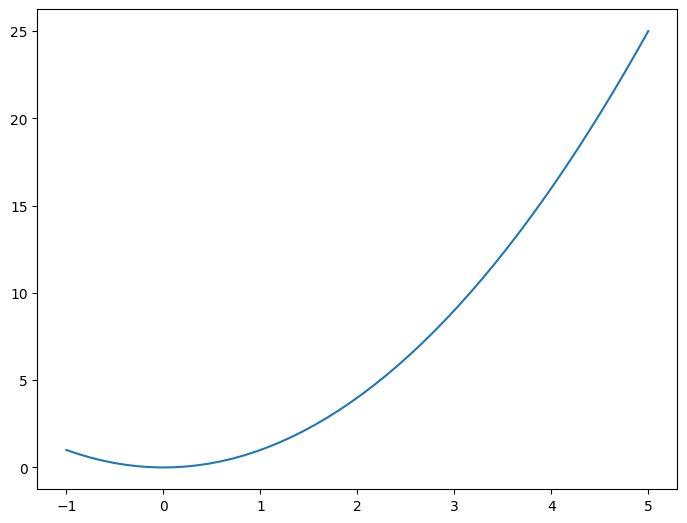

In [2]:
# Vytvoříme jednoduchá data
# (50 bodů rovnoměrně rozmístěných na úsečce -1, 5)
x = np.linspace(-1, 5, 50)
# jejich druhá mocnina (tj. parabola)
y = x ** 2

# nový objekt Figure = prázdný obrázek
fig = plt.figure(figsize=(8, 6))  # velikost obrázku v palcích (šířka, výška)

# U add_axes musíme zadat, jakou část obrázku zabere obdélník se souřadnicemi
# zleva, odspodu, šířka, výška (v relativních hodnotách 0 až 1)
axes = fig.add_axes((0.1, 0.1, 0.8, 0.8))

# Nyní vykreslíme data
graf_funkce = axes.plot(x, y)
# a zobrazíme obrázek
plt.show()

In [3]:
# podívejme se na jednotlivé objekty
print(fig)
print(axes)
print(graf_funkce)

Figure(800x600)
Axes(0.1,0.1;0.8x0.8)


Stejný graf lze vykreslit i jedním voláním `plt.plot(x, y)`. Matplotlib v tom případě vytvoří `Figure` i `Axes` automaticky.

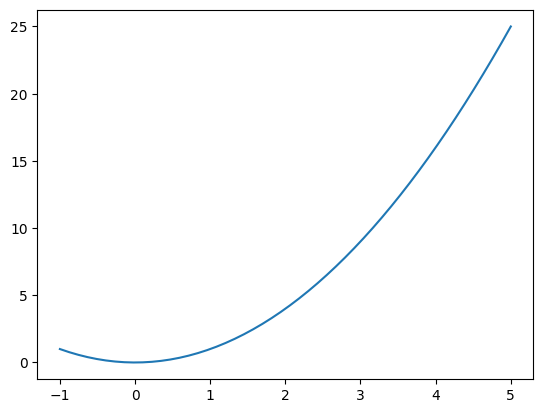

In [4]:
plt.plot(x, y)
# a zobrazíme obrázek
plt.show()

Další datovou řadu přidáme dalším voláním `plot` nad stejným objektem `Axes`.

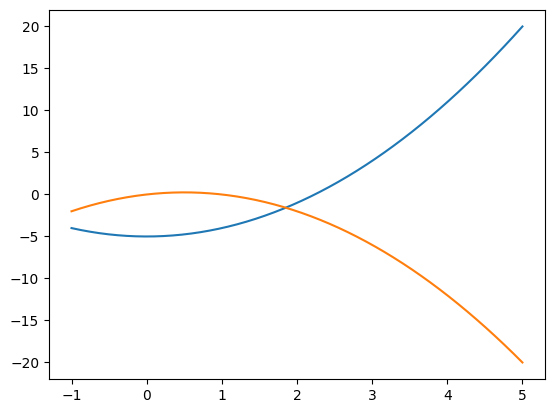

In [5]:
# Kratší získání Figure a Axes
# (pomocí rozdělení obrázku na 1x1 podgraf :-))
fig, axes = plt.subplots()

# Jen voláme vícekrát plot
axes.plot(x, y - 5)
axes.plot(x, x - y)   # druhá datová řada, se automaticky zbarví jinou barvou
# a zobrazíme obrázek
plt.show()

Stejně to funguje i přes rozhraní `plt`.

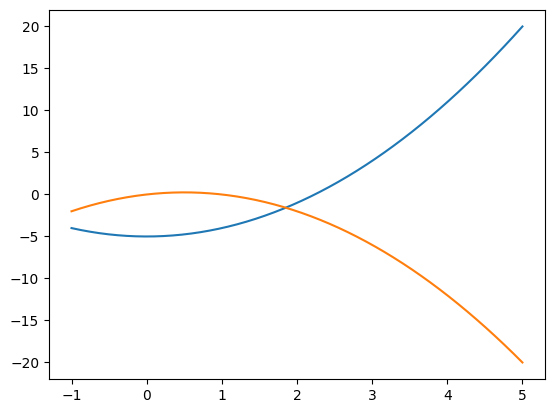

In [6]:
# Jen voláme vícekrát plot
plt.plot(x, y - 5)
plt.plot(x, x - y)   # druhá datová řada, se automaticky zbarví jinou barvou
# a zobrazíme obrázek
plt.show()

Do jednoho volání `plot` lze předat i více dvojic `x, y`.

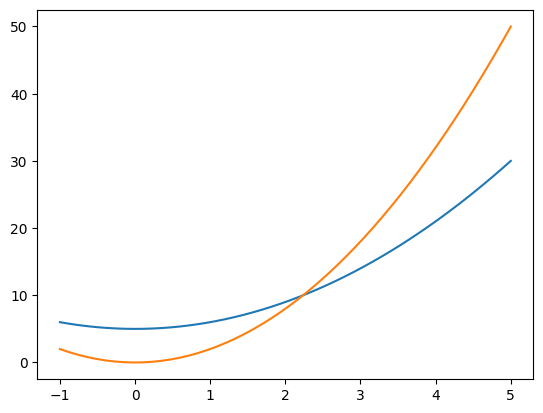

In [7]:
fig, axes = plt.subplots() 

# Dvě datové řady najednou
axes.plot(x, y + 5, x, y * 2)
# a zobrazíme obrázek
plt.show()

(50, 2)
(50, 2)


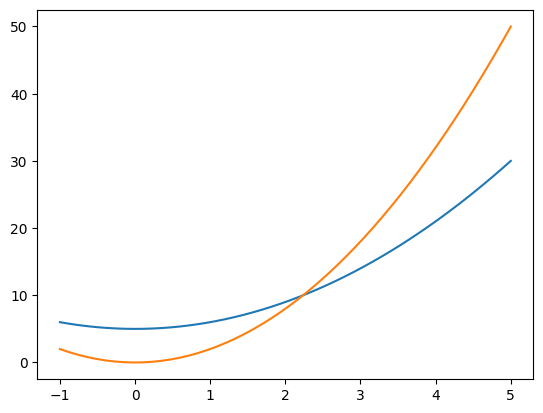

In [8]:
# více grafů najednou lze vykreslit i pomocí sloupcového zápisu
# první argument jsou souřadnice x po sloupcích 
# druhý argument jsou souřadnice y po sloupcích

# uděláme z x sloupcový vektor
x_col = x.reshape((-1,1))
# matici se dvěma sloupci x
xx = np.tile(x_col, (1,2))
print(xx.shape)

# matici se dvěma sloupci hodnot y
yy = np.hstack((x_col ** 2 + 5, 2 * x_col ** 2))
print(yy.shape)

plt.plot(xx,yy)
# a zobrazíme obrázek
plt.show()

# 3. Popisky os

Popisky os i další parametry nastavujeme metodami objektu `Axes` (typicky začínají `set_`).

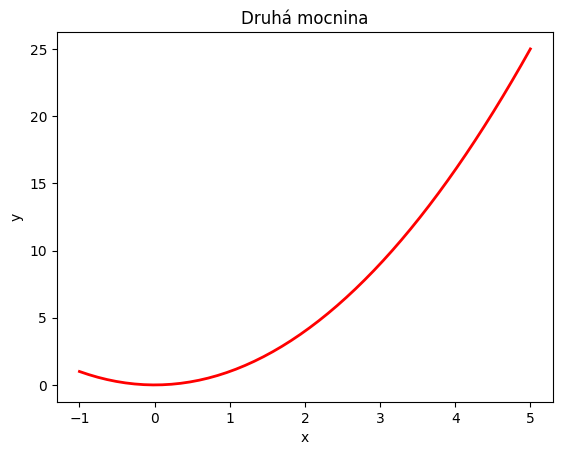

In [9]:
fig, axes = plt.subplots()

axes.plot(x, x ** 2, color='red', linewidth=2)  # Zopakujeme kreslení čárového grafu (+ přidáme styl)
axes.set_xlabel('x')                            # Nastavení popisku osy x
axes.set_ylabel('y')                            # Nastavení popisku osy y
axes.set_title('Druhá mocnina')                 # Nastavení popisku celého grafu (soustavy souřadnic)

plt.show()

Popisky jsou objekty typu **Text**, takže jim můžeme měnit velikost, barvu i font.

findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.


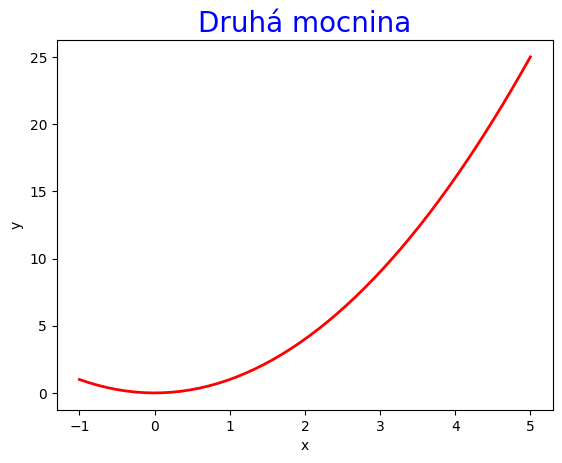

In [10]:
fig, axes = plt.subplots()

axes.plot(x, x ** 2, color='red', linewidth=2)  # Zopakujeme kreslení čárového grafu (+ přidáme styl)
axes.set_xlabel('x')                            # Nastavení popisku osy x
axes.set_ylabel('y')                            # Nastavení popisku osy y
title_text = axes.set_title('Druhá mocnina')    # Nastavení popisku celého grafu (soustavy souřadnic)

title_text.set_fontsize(20)                     # Nastavení velikosti písma
title_text.set_color('blue')                    # Nastavení barvy písma
title_text.set_fontname('Noto Sans')           # Nastavení fontu písma

plt.show()

U jednoho grafu lze stejné nastavení udělat i funkcemi modulu `plt`.

findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.


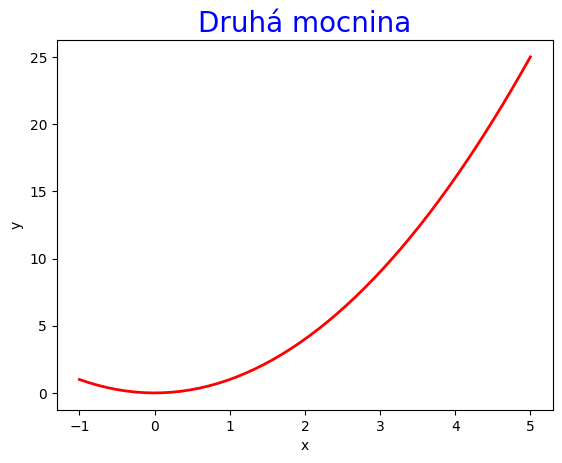

In [11]:
plt.plot(x, x ** 2, color='red', linewidth=2)  # Zopakujeme kreslení čárového grafu (+ přidáme styl)
plt.xlabel('x')                                # Nastavení popisku osy x
plt.ylabel('y')                                # Nastavení popisku osy y
plt.title('Druhá mocnina', fontsize=20, color='blue', fontname='Nimbus Roman')  # Nastavení popisku

plt.show()

# 4. Uložení grafu do souboru

Graf uložíme metodou **savefig**:

findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: 

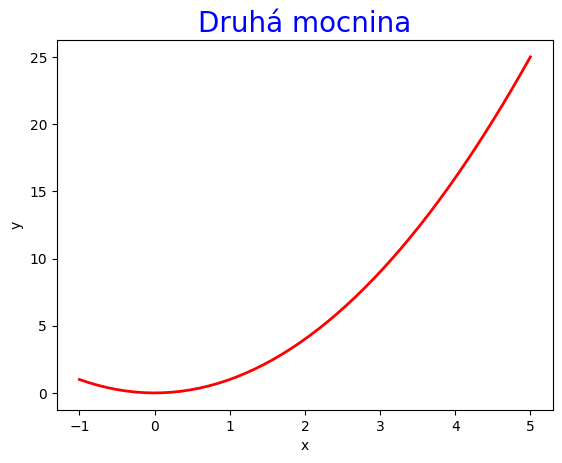

In [12]:
fig, axes = plt.subplots()

axes.plot(x, x ** 2, color='red', linewidth=2)  # Zopakujeme kreslení čárového grafu (+ přidáme styl)
axes.set_xlabel('x')                            # Nastavení popisku osy x
axes.set_ylabel('y')                            # Nastavení popisku osy y
title_text = axes.set_title('Druhá mocnina')    # Nastavení popisku celého grafu (soustavy souřadnic)

title_text.set_fontsize(20)                     # Nastavení velikosti písma
title_text.set_color('blue')                    # Nastavení barvy písma
title_text.set_fontname('Noto Sans')           # Nastavení fontu písma

# Základní uložení (typ souboru podle jména)
fig.savefig("filename.png")

# Parametry
fig.savefig("filename1.png", dpi=50)

# Vektorová grafika
fig.savefig("filename.svg")
fig.savefig("filename.pdf")

# Další možnosti pro PDF výstup (bez bílých okrajů, volitelně průhledné pozadí)
fig.savefig("filename2.pdf", bbox_inches='tight')
fig.savefig("filename3.pdf", bbox_inches='tight', transparent=True)

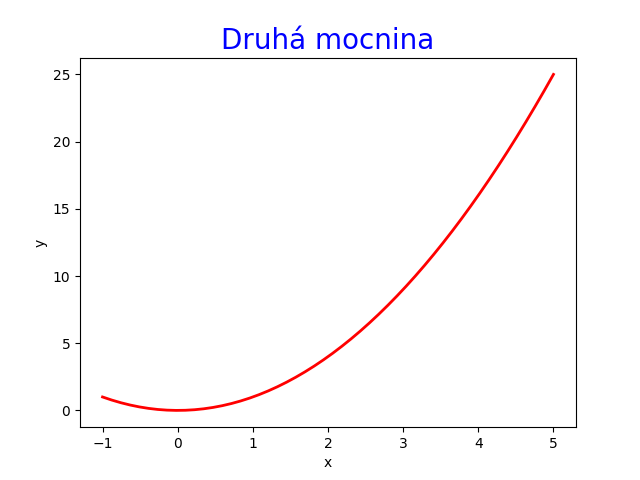

: 

In [ ]:
# Jednoduchý způsob, jak v prostředí Jupyter notebooků zobrazit obrázek ze souboru
from IPython.display import Image
Image(filename="filename.png")